# Example 7 : Finding Events of Interest with Derivatives and HDBSCAN

blah...

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 200 # bigger figures

# Use more REVTEX-esque fonts
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = "STIXGeneral"
mpl.rcParams["mathtext.fontset"] = "stix"

# A derivative, but which?

If we are going to try out using derivatives (taking the differences of $\Delta$E of different strips to try and find events of interest), we have many different options. Ideally, we should try something easy and, ideally, fast. For example we could use NumPy functions. From the [NumPy devdocs](https://numpy.org/devdocs/index.html) we some options we could try, such as

- [numpy.diff](https://numpy.org/devdocs/reference/generated/numpy.diff.html) : Calculate the n-th discrete difference along the given axis. The first difference is given by out[i] = a[i+1] - a[i] along the given axis, higher differences are calculated by using diff recursively.
- [numpy.ediff1d](https://numpy.org/devdocs/reference/generated/numpy.ediff1d.html#numpy.ediff1d) : The differences between consecutive elements of an array.
- [numpy.gradient](https://numpy.org/devdocs/reference/generated/numpy.gradient.html#numpy.gradient) : Return the gradient of an N-dimensional array. The gradient is computed using second order accurate central differences in the interior points and either first or second order accurate one-sides (forward or backwards) differences at the boundaries. The returned gradient hence has the same shape as the input array.


# Get the Data

In [2]:
import uproot

In [3]:
file = uproot.open("test_music_data.root")
tree = file['tree']
branches = tree.arrays()

For simplicity, we can work with the sum of the left and right traces. Here, we will not include the Frisch Grid signal in our dataframe, but we will put the grid into a NumPy array so we don't forget about it.

In [4]:
dict_branches = {}

# strip0 first
dict_branches.update({'s0':branches['strip0'][branches['seg'] == 1]})
# segmented anode, sum left and right
for i in range(1,17):
    dict_branches.update({'s%i' % i : (branches['edepl'][branches['seg'] == i]) + (branches['edepr'][branches['seg'] == i])})
# strip17
dict_branches.update({'s17':branches['strip17'][branches['seg'] == 1]})
#
df = pd.DataFrame(dict_branches)

df

,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17
0,1003.0,416.0,401.0,420.0,377.0,410.0,411.0,417.0,433.0,456.0,451.0,426.0,497.0,497.0,492.0,495.0,494.0,402.0
1,1091.0,397.0,403.0,408.0,397.0,398.0,436.0,392.0,410.0,408.0,449.0,458.0,465.0,466.0,563.0,502.0,522.0,380.0
2,1083.0,426.0,395.0,406.0,410.0,394.0,406.0,401.0,427.0,443.0,444.0,441.0,485.0,484.0,539.0,503.0,522.0,402.0
3,1002.0,405.0,378.0,394.0,417.0,441.0,435.0,428.0,401.0,443.0,451.0,458.0,506.0,472.0,479.0,503.0,504.0,400.0
4,1015.0,393.0,398.0,410.0,421.0,439.0,413.0,411.0,438.0,391.0,422.0,451.0,479.0,477.0,478.0,476.0,506.0,366.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267824,1040.0,401.0,396.0,418.0,413.0,450.0,444.0,405.0,407.0,423.0,423.0,446.0,492.0,464.0,467.0,454.0,498.0,403.0
267825,969.0,366.0,396.0,422.0,399.0,444.0,383.0,419.0,419.0,413.0,419.0,450.0,469.0,475.0,496.0,482.0,517.0,384.0
267826,958.0,376.0,395.0,394.0,398.0,432.0,415.0,402.0,411.0,430.0,434.0,465.0,473.0,459.0,481.0,456.0,497.0,398.0
267827,1006.0,383.0,371.0,430.0,400.0,447.0,419.0,402.0,393.0,411.0,407.0,428.0,475.0,471.0,498.0,489.0,442.0,393.0


In [5]:
grid = np.array(branches['grid'][branches['seg'] == 1], dtype=np.float64)

Now, working with derivatives will also be easier if our data is cleaned up a bit. That is, we should cut pileup using strip 0 and normalize (do our gain matching). For removing pile-up, here we will just do the cuts inplace.

## Remove Pile-up with Strip 0

In [6]:
df.drop(df[800 > df.s0].index, inplace=True) # Nothing with strip 0 smaller than 500
df.drop(df[1350 < df.s0].index, inplace=True) # Nothing with strip 0 larger than 1350

And then a quick normalization across the strips.

## Normalize

In [7]:
from scipy.optimize import curve_fit

In [8]:
gauss = lambda x, a, mu, sigma : a*np.exp(-(x-mu)**2/(2*sigma**2))
norm_factor = []
norm_to = 1000.0
mu_guess = [1000.0, 380.0, 390.0, 395.0, 400.0, 405.0, 410.0, 415.0, 420.0, 425.0,
            430.0, 435.0, 445.0, 455.0, 465.0, 475.0, 485.0, 380.0]

df_norm = df.copy()
# Da loop
for i in range(0,18):
    mean_gauss = 0.0
    counts, bins, patches = plt.hist(df_norm.iloc[:, i], bins=60) # !
    cen_bins = (bins[:-1] + np.diff(bins) / 2)
    # Fit
    param, cov = curve_fit(gauss, cen_bins, counts,
                           p0=(35000, mu_guess[i], 25))
    # Get Mean of Gauss
    mean_gaus = param[1]
    # normalize
    norm_factor.append(norm_to/mean_gaus)
    df_norm.iloc[:, i] = df_norm.iloc[:, i]*(norm_to/mean_gaus)
    # Close
    plt.close()

df_norm.describe()

,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17
count,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000,265787.000000
mean,1003.790344,999.034241,998.883911,999.084106,999.857056,998.142334,998.694031,999.748352,998.526672,999.944397,995.911865,1001.053101,996.172974,999.427063,996.367554,1000.048340,998.161560,999.546509
std,48.192196,40.340229,39.529312,37.271893,39.192669,38.584167,42.561787,39.775852,45.304462,39.319679,46.001774,38.773769,47.191910,37.896542,51.402611,38.472145,55.407406,41.299324
min,817.971985,780.496399,790.350647,797.563110,803.497498,797.325623,750.111816,162.362930,168.891586,160.850067,151.217026,151.893112,144.864914,146.875214,139.116089,135.547150,142.641800,65.794037
25%,972.802368,973.118896,974.510010,974.522400,975.142517,972.460693,971.842957,974.177551,972.332947,974.562195,970.497375,977.103516,969.965088,977.039490,967.764160,977.582520,966.347961,974.257812
50%,1001.041870,1000.636414,1000.087708,999.446228,1000.018616,997.809204,1000.149048,1000.834106,998.873047,1000.582092,997.581055,1002.041199,997.258484,998.325745,1000.022949,1000.173706,1000.501648,999.563171
75%,1030.255127,1025.652344,1025.665405,1024.370117,1024.894653,1023.157715,1026.096313,1025.067383,1027.825928,1024.236450,1024.664673,1024.711792,1024.551880,1021.740662,1026.233154,1022.764893,1028.628174,1022.338074
max,1314.597778,1876.193237,3007.936523,2372.750244,2646.815430,2868.989502,2691.438965,2687.469971,3042.461182,2876.377930,2949.860596,2779.417480,2796.522705,2473.463867,2616.995605,2382.343994,2760.420166,2406.543213


# Taking Derivatives of Traces

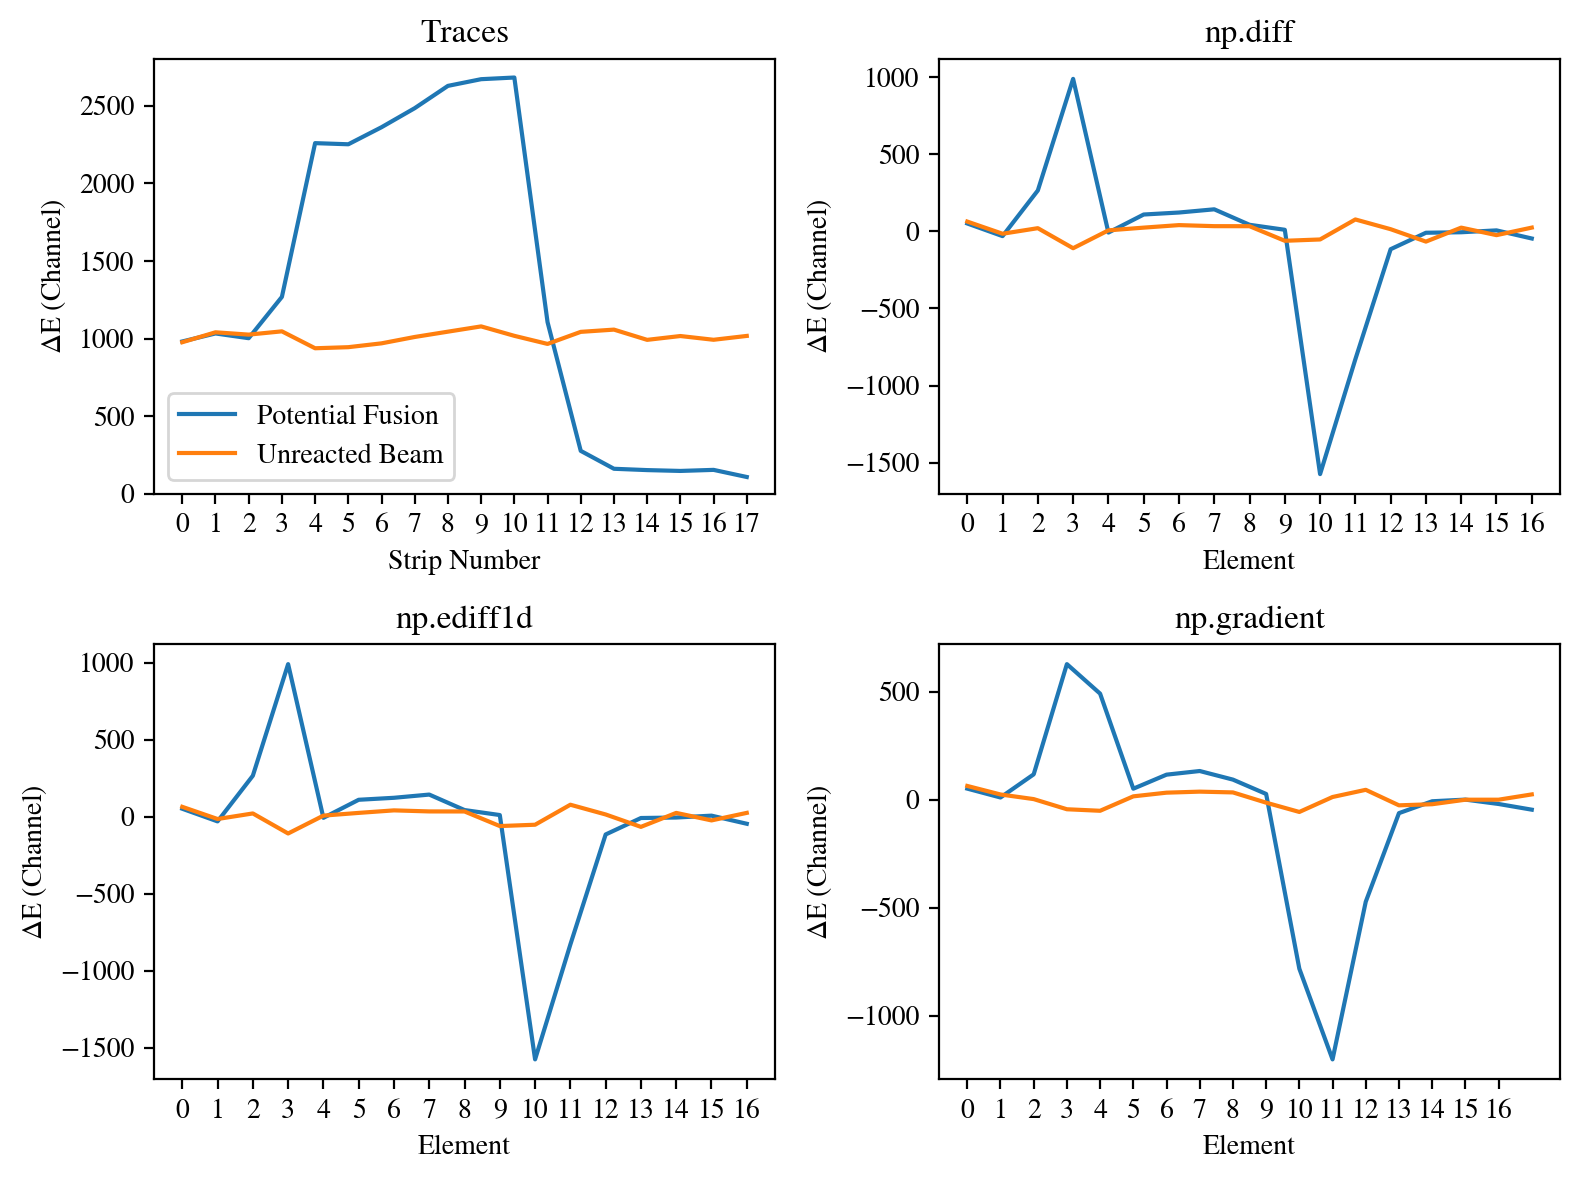

In [9]:
fig, ax = plt.subplots(2,2)

strip_num = np.arange(0,18)
# top left
ax[0,0].set_title('Traces')
ax[0,0].plot(strip_num, df_norm.loc[259531, :], label='Potential Fusion')
ax[0,0].plot(strip_num, df_norm.loc[0, :], label='Unreacted Beam')
# top right
ax[0,1].set_title('np.diff')
ax[0,1].plot(strip_num[:-1], np.diff(df_norm.loc[259531, :]), label='Potential Fusion')
ax[0,1].plot(strip_num[:-1], np.diff(df_norm.loc[0, :]), label='Unreacted Beam')
# bottom left
ax[1,0].set_title('np.ediff1d')
ax[1,0].plot(strip_num[:-1], np.ediff1d(df_norm.loc[259531, :]), label='Potential Fusion')
ax[1,0].plot(strip_num[:-1], np.ediff1d(df_norm.loc[0, :]), label='Unreacted Beam')
# bottom right
ax[1,1].set_title('np.gradient')
ax[1,1].plot(strip_num, np.gradient(df_norm.loc[259531, :]), label='Potential Fusion')
ax[1,1].plot(strip_num, np.gradient(df_norm.loc[0, :]), label='Unreacted Beam')
#
for i in (0,1):
    for j in (0,1):
        ax[i,j].set_xlabel('Element')
        ax[i,j].set_xticks(strip_num[:-1], strip_num[:-1])
        ax[i,j].set_ylabel(r'$\Delta$E (Channel)')
#
ax[0,0].set_xlabel('Strip Number')
ax[0,0].set_xticks(strip_num, strip_num)
ax[0,0].set_ylabel(r'$\Delta$E (Channel)')
ax[0,0].set_ylim(0,2800)

ax[0,0].legend()
fig.set_size_inches(8,6)
plt.tight_layout()
plt.show()

Among the different NumPy functions we used, the overall "effect" is the same (as should be expected). We see a jump in the derivative which corresponds with the jump in $\Delta$E. Over the flat part of the fusion trace, the derivative goes back down to around zero. Finally, when the trace begins to fall, we see another jump, this time negative, in the derivative here as well. For the unreacted beam trace, we see that basically, the derivative is flat. Looking at the potential fusion trace, this appears to be an event in strip 3, and the maximum value of the derivative is in element 3. 

With `gradient` we can see some more sensitivity to the "shape" of the trace, `gradient` may have some benefits in that way. Using the derivatives, we can see there is also a potential way to define a "simple range" of the heavy recoil. For example, one could take the element where the derivative has its minimum value and subtract the element number where the derivative has its maximum. In this case using `ediff` and `ediff1d` you get 10 - 3 for a "simple range" of 7 strips. With the `gradient` the minimum is at a different element, giving instead a range of 8 strips which looking at the trace in the top left plot seems more accurate. However, one shouldn't take this to mean `gradient` is the preferred option; one should test over several candidate traces to see if one method is better than the other for your data. Finally, we note that with `ediff` and `ediff1d` the output array that is returned is smaller than the input array by one (input had length 17, output is length 16), but `gradient` returns an array the same length as the input. Something to remember when trying to plot derivatives.

# Testing Different Trace Metrics for Event Analysis

Looking at the derrivative array works well with plots, if we just want to look at some traces in one plot and their derivatives in another plot it works pretty good. In a very visual way you can identify potential events and get more information about how to refine your cuts. However, it might also be nice to just have one number that you can use to help you in your analsis (one more thing you can use in 2D histogram). Let's do some simple tests creating metrics that we define from the derivatives we calculated. One metric could be the maximum value of the derivative. Another metric could be which element in the derivative contains that maximum value.

In [10]:
strip_columns = df_norm.columns[:18]
data = df_norm[strip_columns].to_numpy()

### Trace Metrics from Derivatives

Here getting the max derivative metric and the element where the maximum is can be obtained quickly using `max` and `argmax` in NumPy.

In [11]:
# Maximum value of np.diff and element with max np.diff
diffs = np.diff(data, axis=1)
df_norm['maxDIFF'] = np.max(diffs, axis=1)
df_norm['argDIFF'] = np.argmax(diffs, axis=1)
# Maximum value of np.gradient and element with max np.gradient
grad = np.gradient(data, axis=1)
df_norm['maxGRAD'] = np.max(grad, axis=1)
df_norm['argGRAD'] = np.argmax(grad, axis=1)

Another metric, one that doesn't depend on the derivative, would be to take the maximum $\Delta$E of the trace.

In [12]:
df_norm['maxDE'] = df_norm.iloc[:,0:18].max(axis=1)

Let's do a quick `seaborn.pairplot` and see what these look like.

In [13]:
import seaborn as sns
import warnings

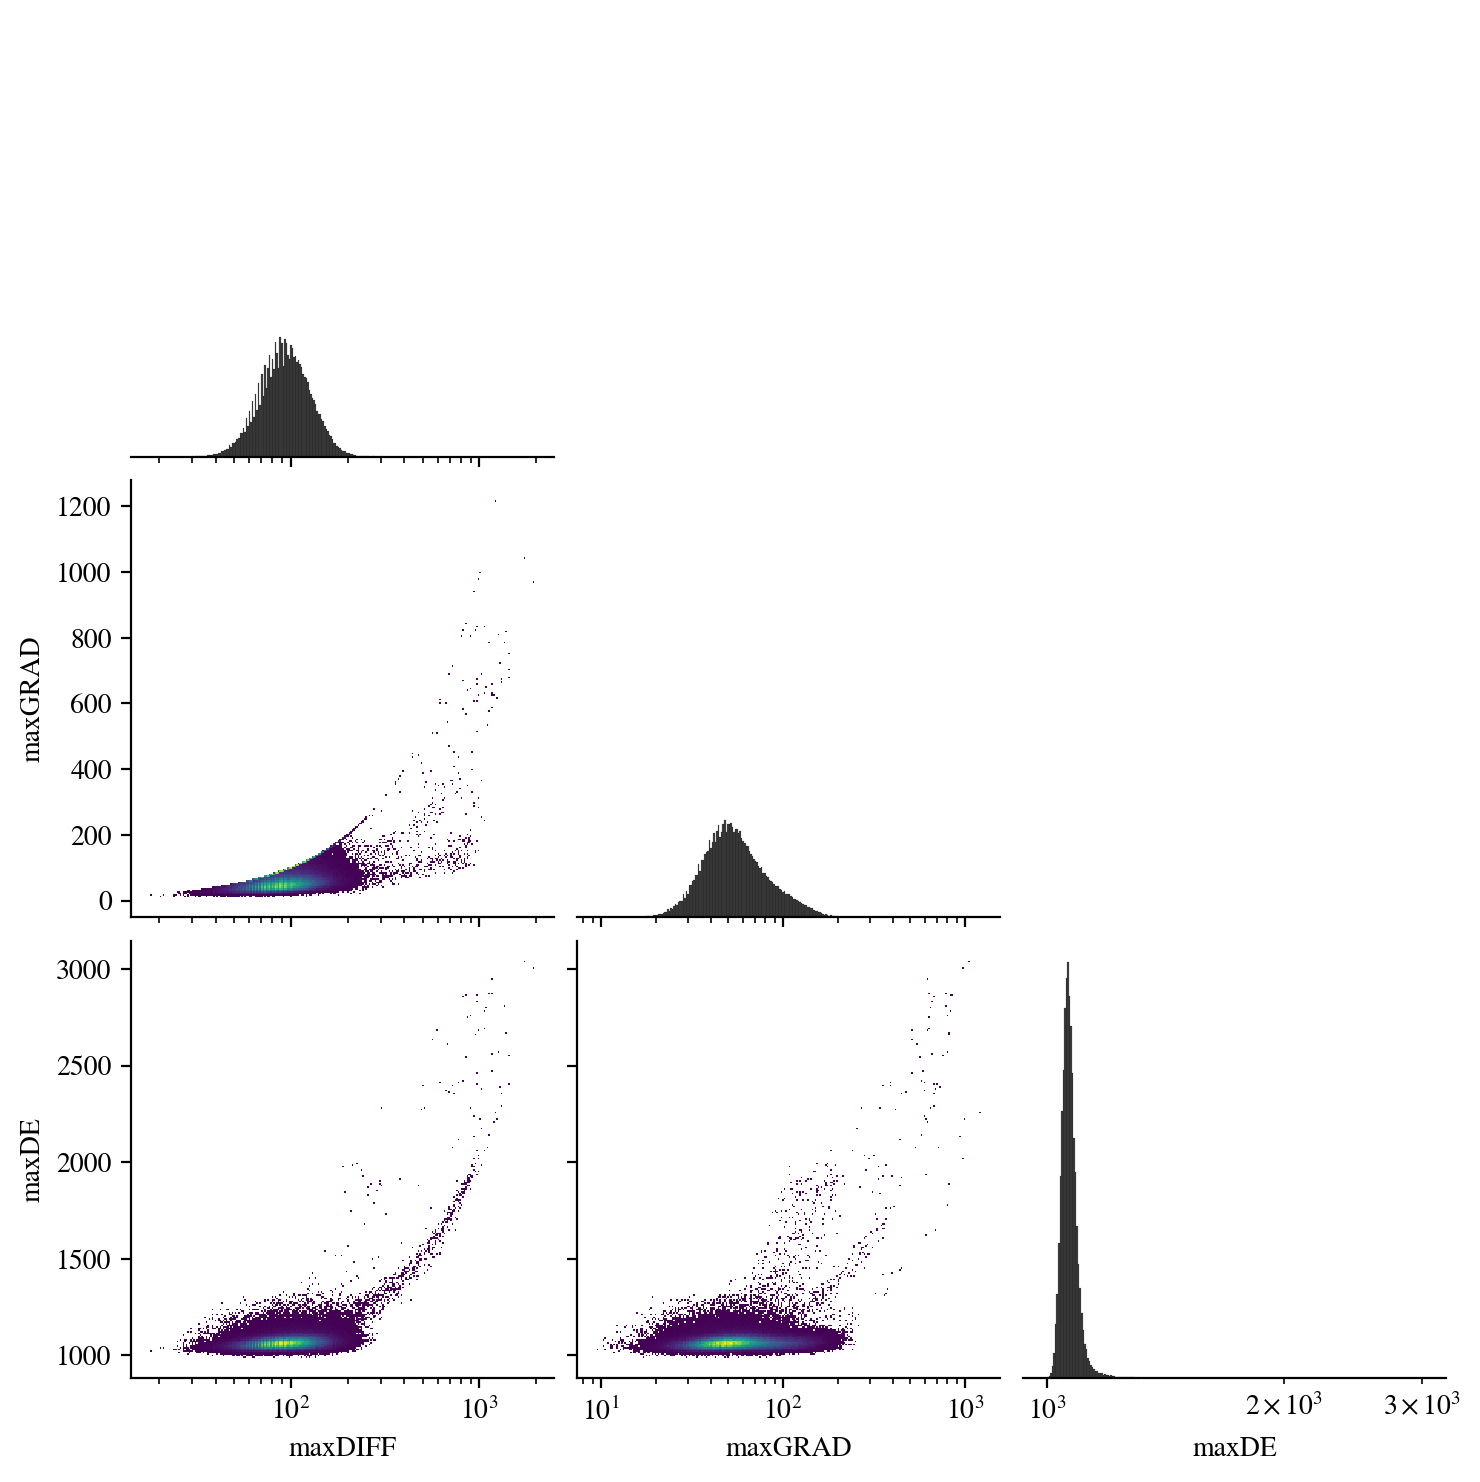

In [14]:
# Surpress UserWarning about changed layout
warnings.filterwarnings('ignore')

sns.pairplot(df_norm, vars=('maxDIFF', 'maxGRAD', 'maxDE'), 
             kind='hist',
             corner=True,
             plot_kws={'bins':250, 'cmap':'viridis'},
             diag_kws={'bins':250, 'color':'black', 'log_scale':True})

In the 2D histograms, we can see a high-density blob, likely the unreacted beam events. From this high-density blob, we do see these tendril like outshoots. For the maxDE vs. maxGRAD and maxGRAD vs. maxDIFF it looks like there is even some structure (maybe three tendrils that could become more clear with more statistics). Let's try using maxDIFF with another metric. Previously we discussed using the derivative to compute a range like quantity, we can try that using `numpy.argmax` and `numpy.argmin`.

In [15]:
diffs = np.diff(data, axis=1)
df_norm['intRANGE'] = np.abs(np.argmax(diffs, axis=1) - np.argmin(diffs, axis=1))

In [16]:
import matplotlib.patches as mpatches

Now we can test out some cuts using our two metrics and plot the resulting traces. We can also add another condition on strip 17 to prevent some of the oddball zig-zag traces from overwhelming our plot.

In [17]:
iRcut = [1.5,12.5] # [lower, upper]
mDcut = [475,1475] # [lower, upper]
# intRANGE cut
df_cut = df_norm.drop(df_norm[iRcut[0] > df_norm.intRANGE].index, inplace=False) 
df_cut.drop(df_cut[iRcut[1] < df_cut.intRANGE].index, inplace=True)
# maxDIFF cut
df_cut.drop(df_cut[mDcut[0] > df_cut.maxDIFF].index, inplace=True)
df_cut.drop(df_cut[mDcut[1] < df_cut.maxDIFF].index, inplace=True)
# must be less than beam in s17
df_cut.drop(df_cut[750 < df_cut.s17].index, inplace=True)

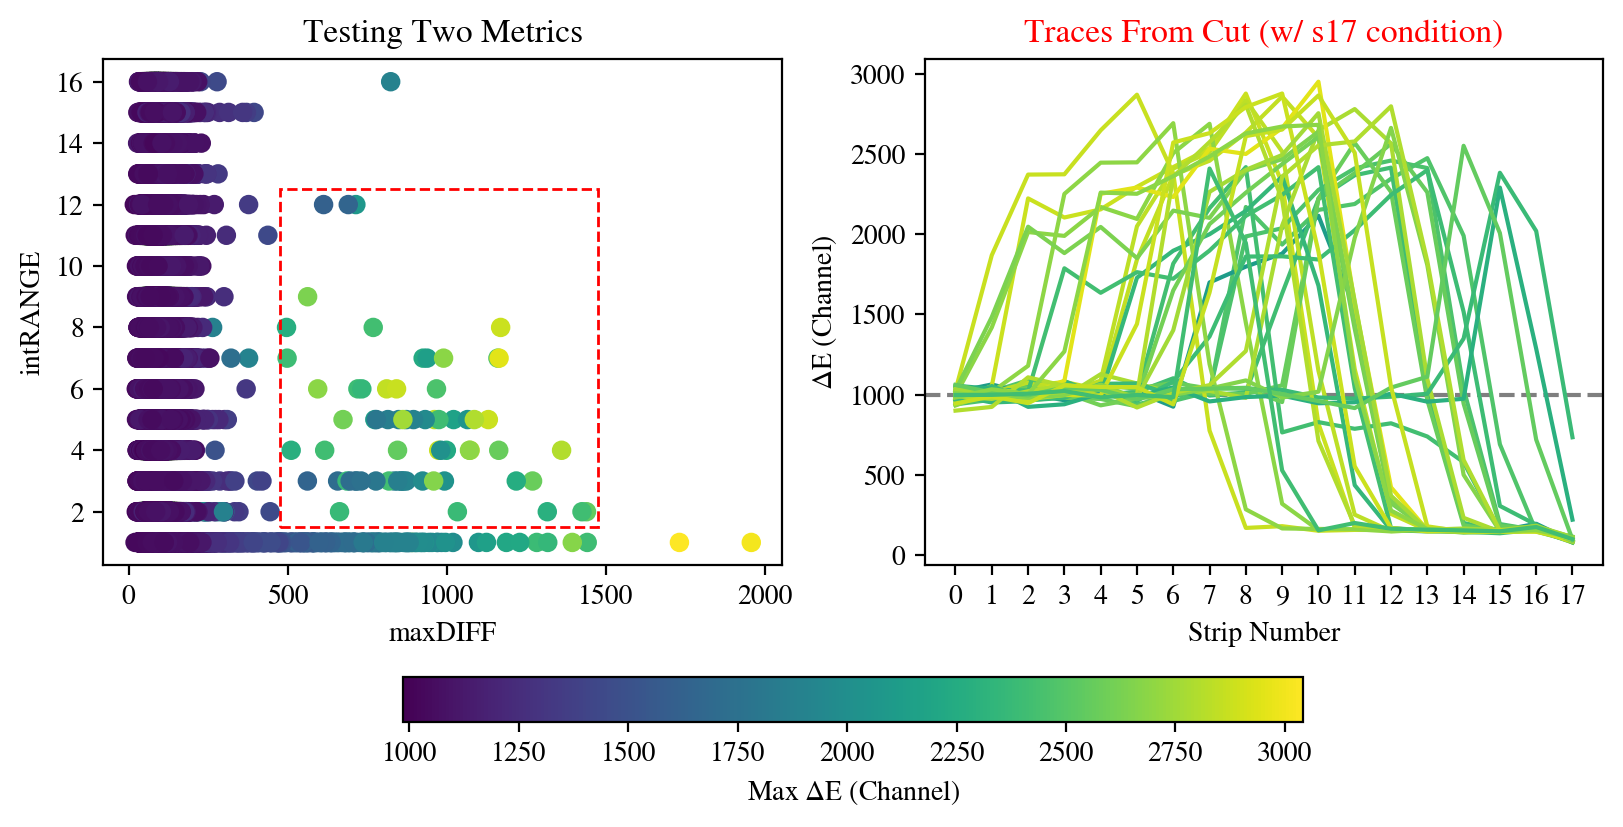

In [18]:
fig, ax = plt.subplots(1,2, layout='constrained')
# scatter
ax[0].set_title('Testing Two Metrics')
scplt = ax[0].scatter(df_norm['maxDIFF'], df_norm['intRANGE'], c=df_norm['maxDE'])
# viz the cut
rect_cut = mpatches.Rectangle((mDcut[0],iRcut[0]), mDcut[1]-mDcut[0], iRcut[1]-iRcut[0],
                              edgecolor='r',
                              fill=False,
                              linestyle='--')
# rect_cut = mpatches.Rectangle((475,1.5), 1000, 11, edgecolor='r', fill=False, linestyle='--')
ax[0].add_patch(rect_cut)
# traces in Cut
## cmap values to match scatter
cmap = plt.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=df_norm['maxDE'].min(), vmax=df_norm['maxDE'].max())
colors = cmap(norm(df_cut['maxDE']))
# plot traces
ax[1].set_title('Traces From Cut (w/ s17 condition)', c='r')
for i in range(len(df_cut.index)):
    ax[1].plot(strip_num, df_cut.iloc[i,0:18], color=colors[i], zorder=10)
# viz beam avg
ax[1].axhline(1000.0, c='k', linestyle='--', alpha=0.5, zorder=1)
# cbar
fig.colorbar(scplt, ax=[ax[0],ax[1]],
             location='bottom',
             shrink=0.6,
             label=r'Max $\Delta$E (Channel)')
#
ax[0].set_xlabel('maxDIFF')
ax[0].set_ylabel('intRANGE')
#
ax[1].set_xlabel('Strip Number')
ax[1].set_xticks(strip_num, strip_num)
ax[1].set_ylabel(r'$\Delta$E (Channel)')

fig.set_size_inches(8,4)
plt.show()

### Trace Metrics from "Shape"

There are other metrics we can compute using the derivatives. For example, we could setup metrics that sum over elements of the derivitve array instead of just using the min or max values. Instead of simpling summing over the elements of the array, we could use a cumulative sum instead which should have some more sensitivity to the different shapes of the traces. Again, we can do a quick plot to see what this might look like.

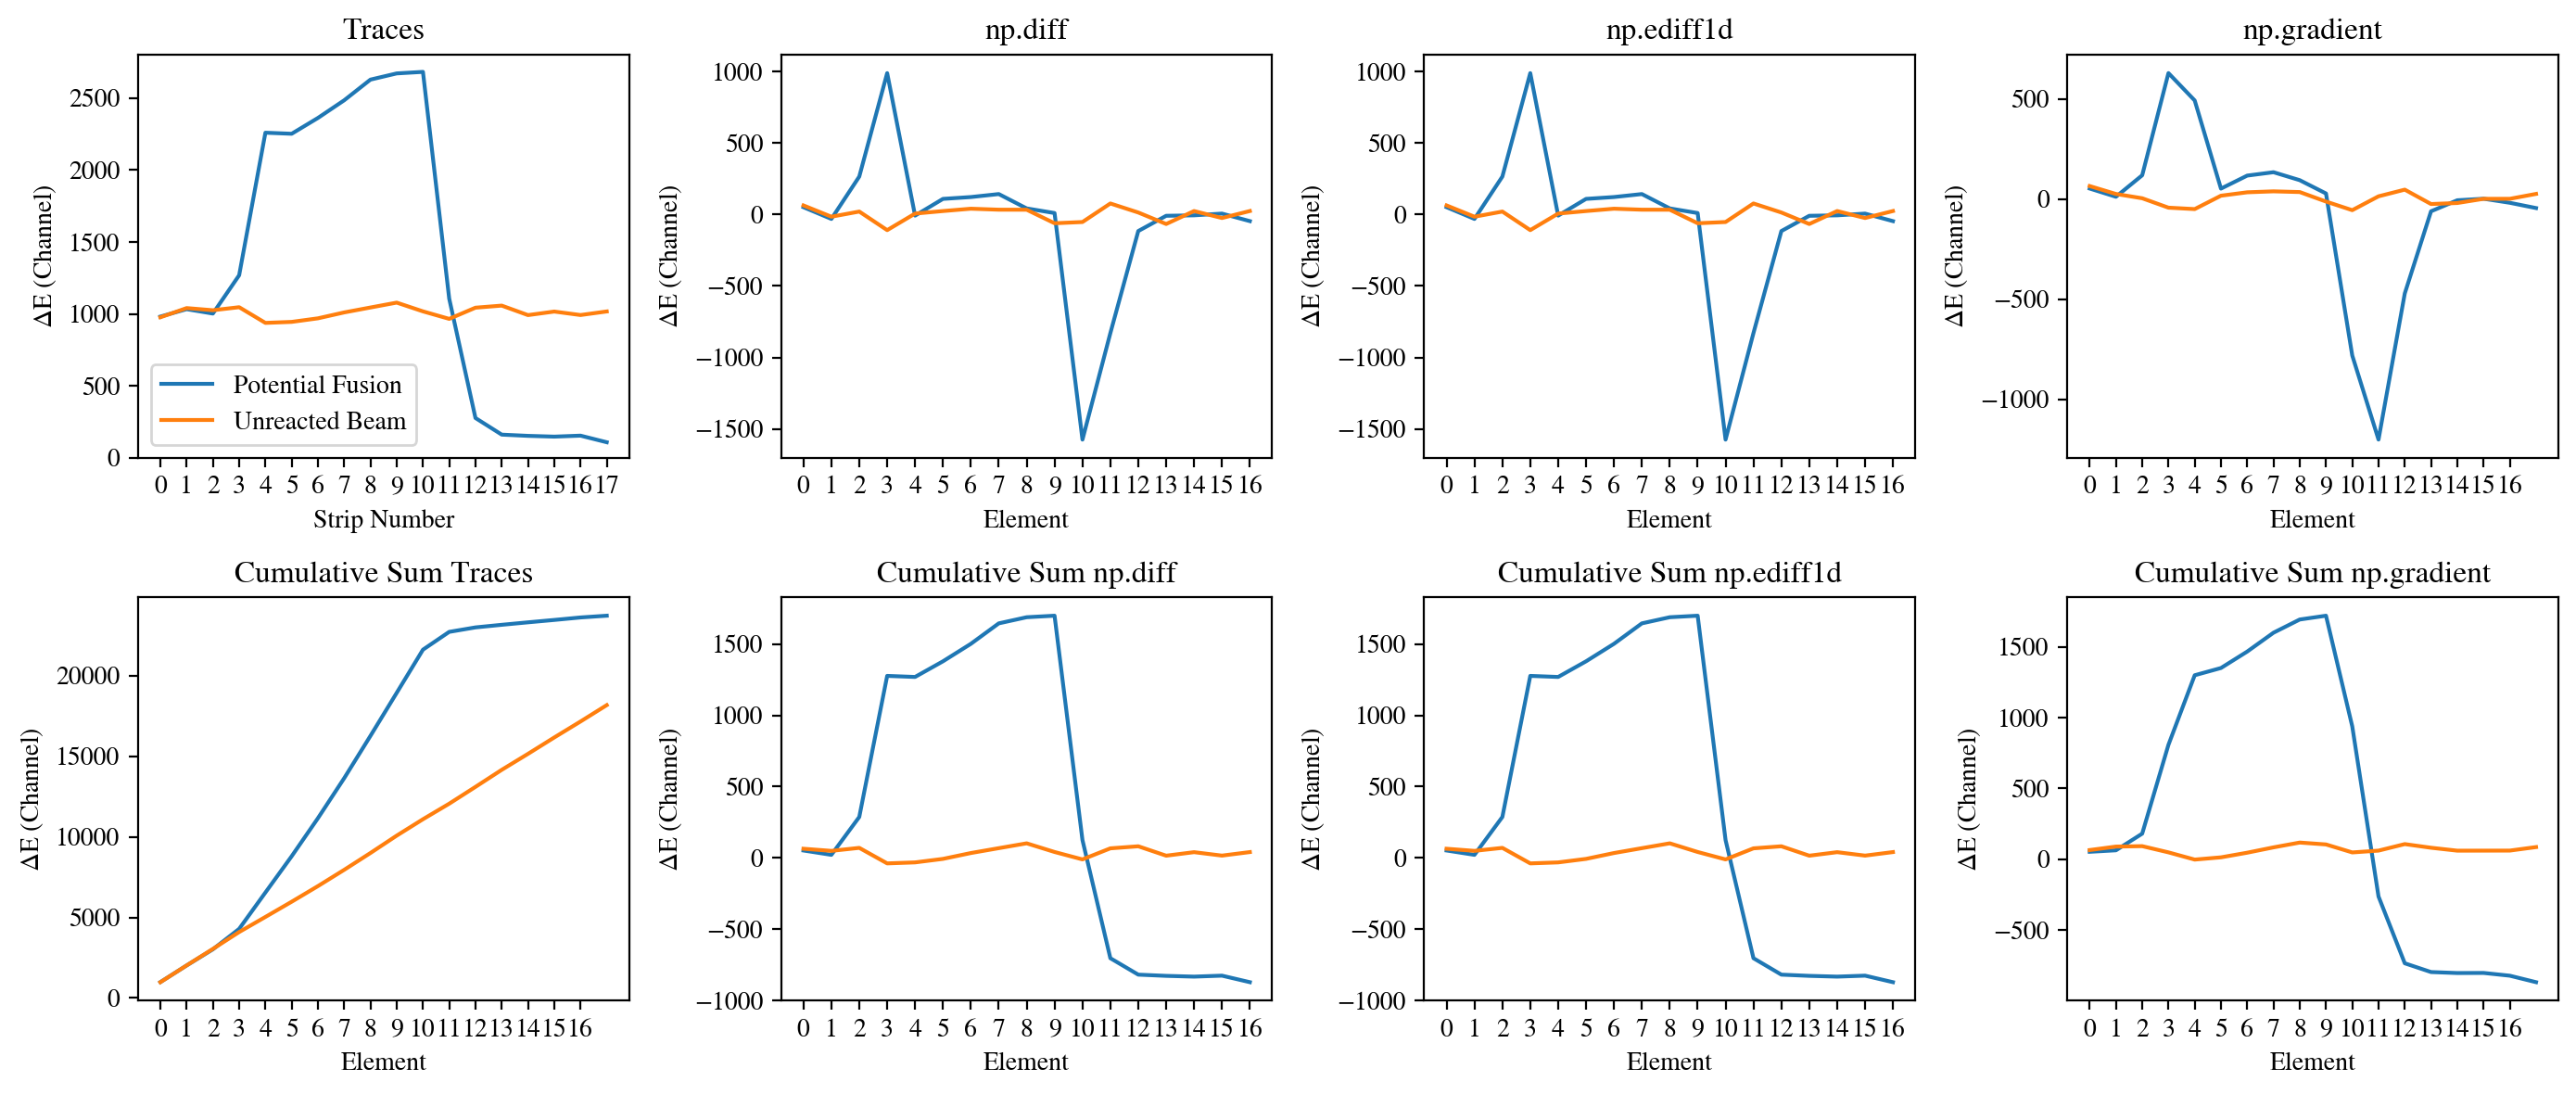

In [19]:
fig, ax = plt.subplots(2,4)

strip_num = np.arange(0,18)
# top
ax[0,0].set_title('Traces')
ax[0,0].plot(strip_num, df_norm.loc[259531, 's0':'s17'], label='Potential Fusion')
ax[0,0].plot(strip_num, df_norm.loc[0, 's0':'s17'], label='Unreacted Beam')
#
ax[0,1].set_title('np.diff')
ax[0,1].plot(strip_num[:-1], np.diff(df_norm.loc[259531, 's0':'s17']), label='Potential Fusion')
ax[0,1].plot(strip_num[:-1], np.diff(df_norm.loc[0, 's0':'s17']), label='Unreacted Beam')
#
ax[0,2].set_title('np.ediff1d')
ax[0,2].plot(strip_num[:-1], np.ediff1d(df_norm.loc[259531, 's0':'s17']), label='Potential Fusion')
ax[0,2].plot(strip_num[:-1], np.ediff1d(df_norm.loc[0, 's0':'s17']), label='Unreacted Beam')
#
ax[0,3].set_title('np.gradient')
ax[0,3].plot(strip_num, np.gradient(df_norm.loc[259531, 's0':'s17']), label='Potential Fusion')
ax[0,3].plot(strip_num, np.gradient(df_norm.loc[0, 's0':'s17']), label='Unreacted Beam')
# bottom
ax[1,0].set_title('Cumulative Sum Traces')
ax[1,0].plot(strip_num, np.cumsum(df_norm.loc[259531, 's0':'s17']), label='Potential Fusion')
ax[1,0].plot(strip_num, np.cumsum(df_norm.loc[0, 's0':'s17']), label='Unreacted Beam')
#
ax[1,1].set_title('Cumulative Sum np.diff')
ax[1,1].plot(strip_num[:-1], np.cumsum(np.diff(df_norm.loc[259531, 's0':'s17'])), label='Potential Fusion')
ax[1,1].plot(strip_num[:-1], np.cumsum(np.diff(df_norm.loc[0, 's0':'s17'])), label='Unreacted Beam')
#
ax[1,2].set_title('Cumulative Sum np.ediff1d')
ax[1,2].plot(strip_num[:-1], np.cumsum(np.ediff1d(df_norm.loc[259531, 's0':'s17'])), label='Potential Fusion')
ax[1,2].plot(strip_num[:-1], np.cumsum(np.ediff1d(df_norm.loc[0, 's0':'s17'])), label='Unreacted Beam')
#
ax[1,3].set_title('Cumulative Sum np.gradient')
ax[1,3].plot(strip_num, np.cumsum(np.gradient(df_norm.loc[259531, 's0':'s17'])), label='Potential Fusion')
ax[1,3].plot(strip_num, np.cumsum(np.gradient(df_norm.loc[0, 's0':'s17'])), label='Unreacted Beam')

for i in (0,1):
    for j in (0,1,2,3):
        ax[i,j].set_xlabel('Element')
        ax[i,j].set_xticks(strip_num[:-1], strip_num[:-1])
        ax[i,j].set_ylabel(r'$\Delta$E (Channel)')
#
ax[0,0].set_xlabel('Strip Number')
ax[0,0].set_xticks(strip_num, strip_num)
ax[0,0].set_ylabel(r'$\Delta$E (Channel)')
ax[0,0].set_ylim(0,2800)

ax[0,0].legend()
fig.set_size_inches(14,6)
plt.tight_layout()
plt.show()

The top four plots show the traces and the different derivatives we tried out earlier. The four bottom plots show the cumulative sums of the curves in the top plots. Taking the cumulative sum of the traces themselves shows how useful our normalization was, the jump in $\Delta$E for a fusion event leads to a noticeably different curve compared to unreacted beam events. With the cumulative sums of the derivatives, at first glance, it looks like all we did was sort of undo the derivative. However, for `ediff` and `ediff1d` we shifted the trace such that now when the $\Delta$E goes below the beam the cumulative sum of the derivative becomes negative. And for the `gradient` again, we see there is more sensitivity to the shape of the input trace. 

Let's try another test, where we use the cumulative sum of the trace and the derivative to get an analog to the total energy. For the cumulative sum of the trace, since the beam in this data does not stop in the detector, we could assume unreacted beam events have $\Delta$E=1000 for all strips and use that to offset the cumulative sum for non-beam events. With the derivative, we could get a total energy from summing over only the positive values of the array.

In [20]:
# cumulative sum of trace, offset to get fusion component
df_norm['relTotE'] = np.sum(np.cumsum(data, axis=1), axis=1) - np.sum(np.cumsum(np.tile(1000.0, 18)))
# sum over the 
grad = np.gradient(data, axis=1)
cs_grad = np.cumsum(grad, axis=1)
pos_grad = np.sum(cs_grad, axis=1, where=cs_grad > 0)
df_norm['gradTotE'] = pos_grad

In [21]:
df_norm

,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9,...,s16,s17,maxDIFF,argDIFF,maxGRAD,argGRAD,maxDE,intRANGE,relTotE,gradTotE
0,976.697510,1040.661865,1025.665405,1046.801514,937.828369,944.807800,969.484131,1010.527466,1044.715088,1078.641724,...,992.465454,1017.276978,77.679077,11,63.964355,0,1078.641724,8,1174.796875,1210.388306
1,1062.389771,993.131592,1030.780884,1016.892944,987.580566,917.154907,1028.455200,949.944275,989.222107,965.100464,...,1048.718628,961.605103,143.166809,13,79.421539,13,1135.106689,1,755.171875,0.000000
2,1054.599609,1065.677734,1010.318787,1011.908203,1019.919434,907.937256,957.689880,971.754211,1030.238647,1047.890869,...,1048.718628,1017.276978,58.484436,7,38.068329,8,1086.718506,3,2276.734375,31.319946
3,975.723694,1013.144348,966.836731,981.999573,1037.332764,1016.244507,1026.096313,1037.184082,967.507507,1047.890869,...,1012.555847,1012.215881,80.383362,8,37.420654,0,1062.342773,1,1356.359375,1008.611572
4,988.382812,983.125244,1017.992065,1021.877686,1047.283203,1011.635681,974.201782,995.987488,1056.778809,924.887939,...,1016.573914,926.177551,70.003113,10,48.778381,10,1056.778809,2,105.687500,206.365387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267824,1012.727234,1003.138000,1012.876526,1041.816772,1027.382324,1036.984131,1047.325928,981.447510,981.983887,1000.582092,...,1000.501648,1019.807495,68.101501,15,43.703674,16,1047.325928,9,1604.453125,82.643402
267825,943.589111,915.582275,1012.876526,1051.786377,992.555786,1023.157715,903.436523,1015.374084,1010.936768,976.927673,...,1038.673340,971.727295,111.937561,6,68.102051,2,1051.786377,1,-2669.828125,599.434509
267826,932.877563,940.598206,1010.318787,981.999573,990.068176,995.504822,978.919495,974.177551,991.634888,1017.140198,...,998.492554,1007.154846,74.658325,10,38.720612,1,1054.183594,1,-3234.984375,1048.141968
267827,979.618835,958.109314,948.932312,1071.725464,995.043396,1030.070923,988.354858,974.177551,948.205627,972.196777,...,887.995422,994.502136,122.793152,2,106.506714,17,1071.725464,13,-2753.796875,197.658234


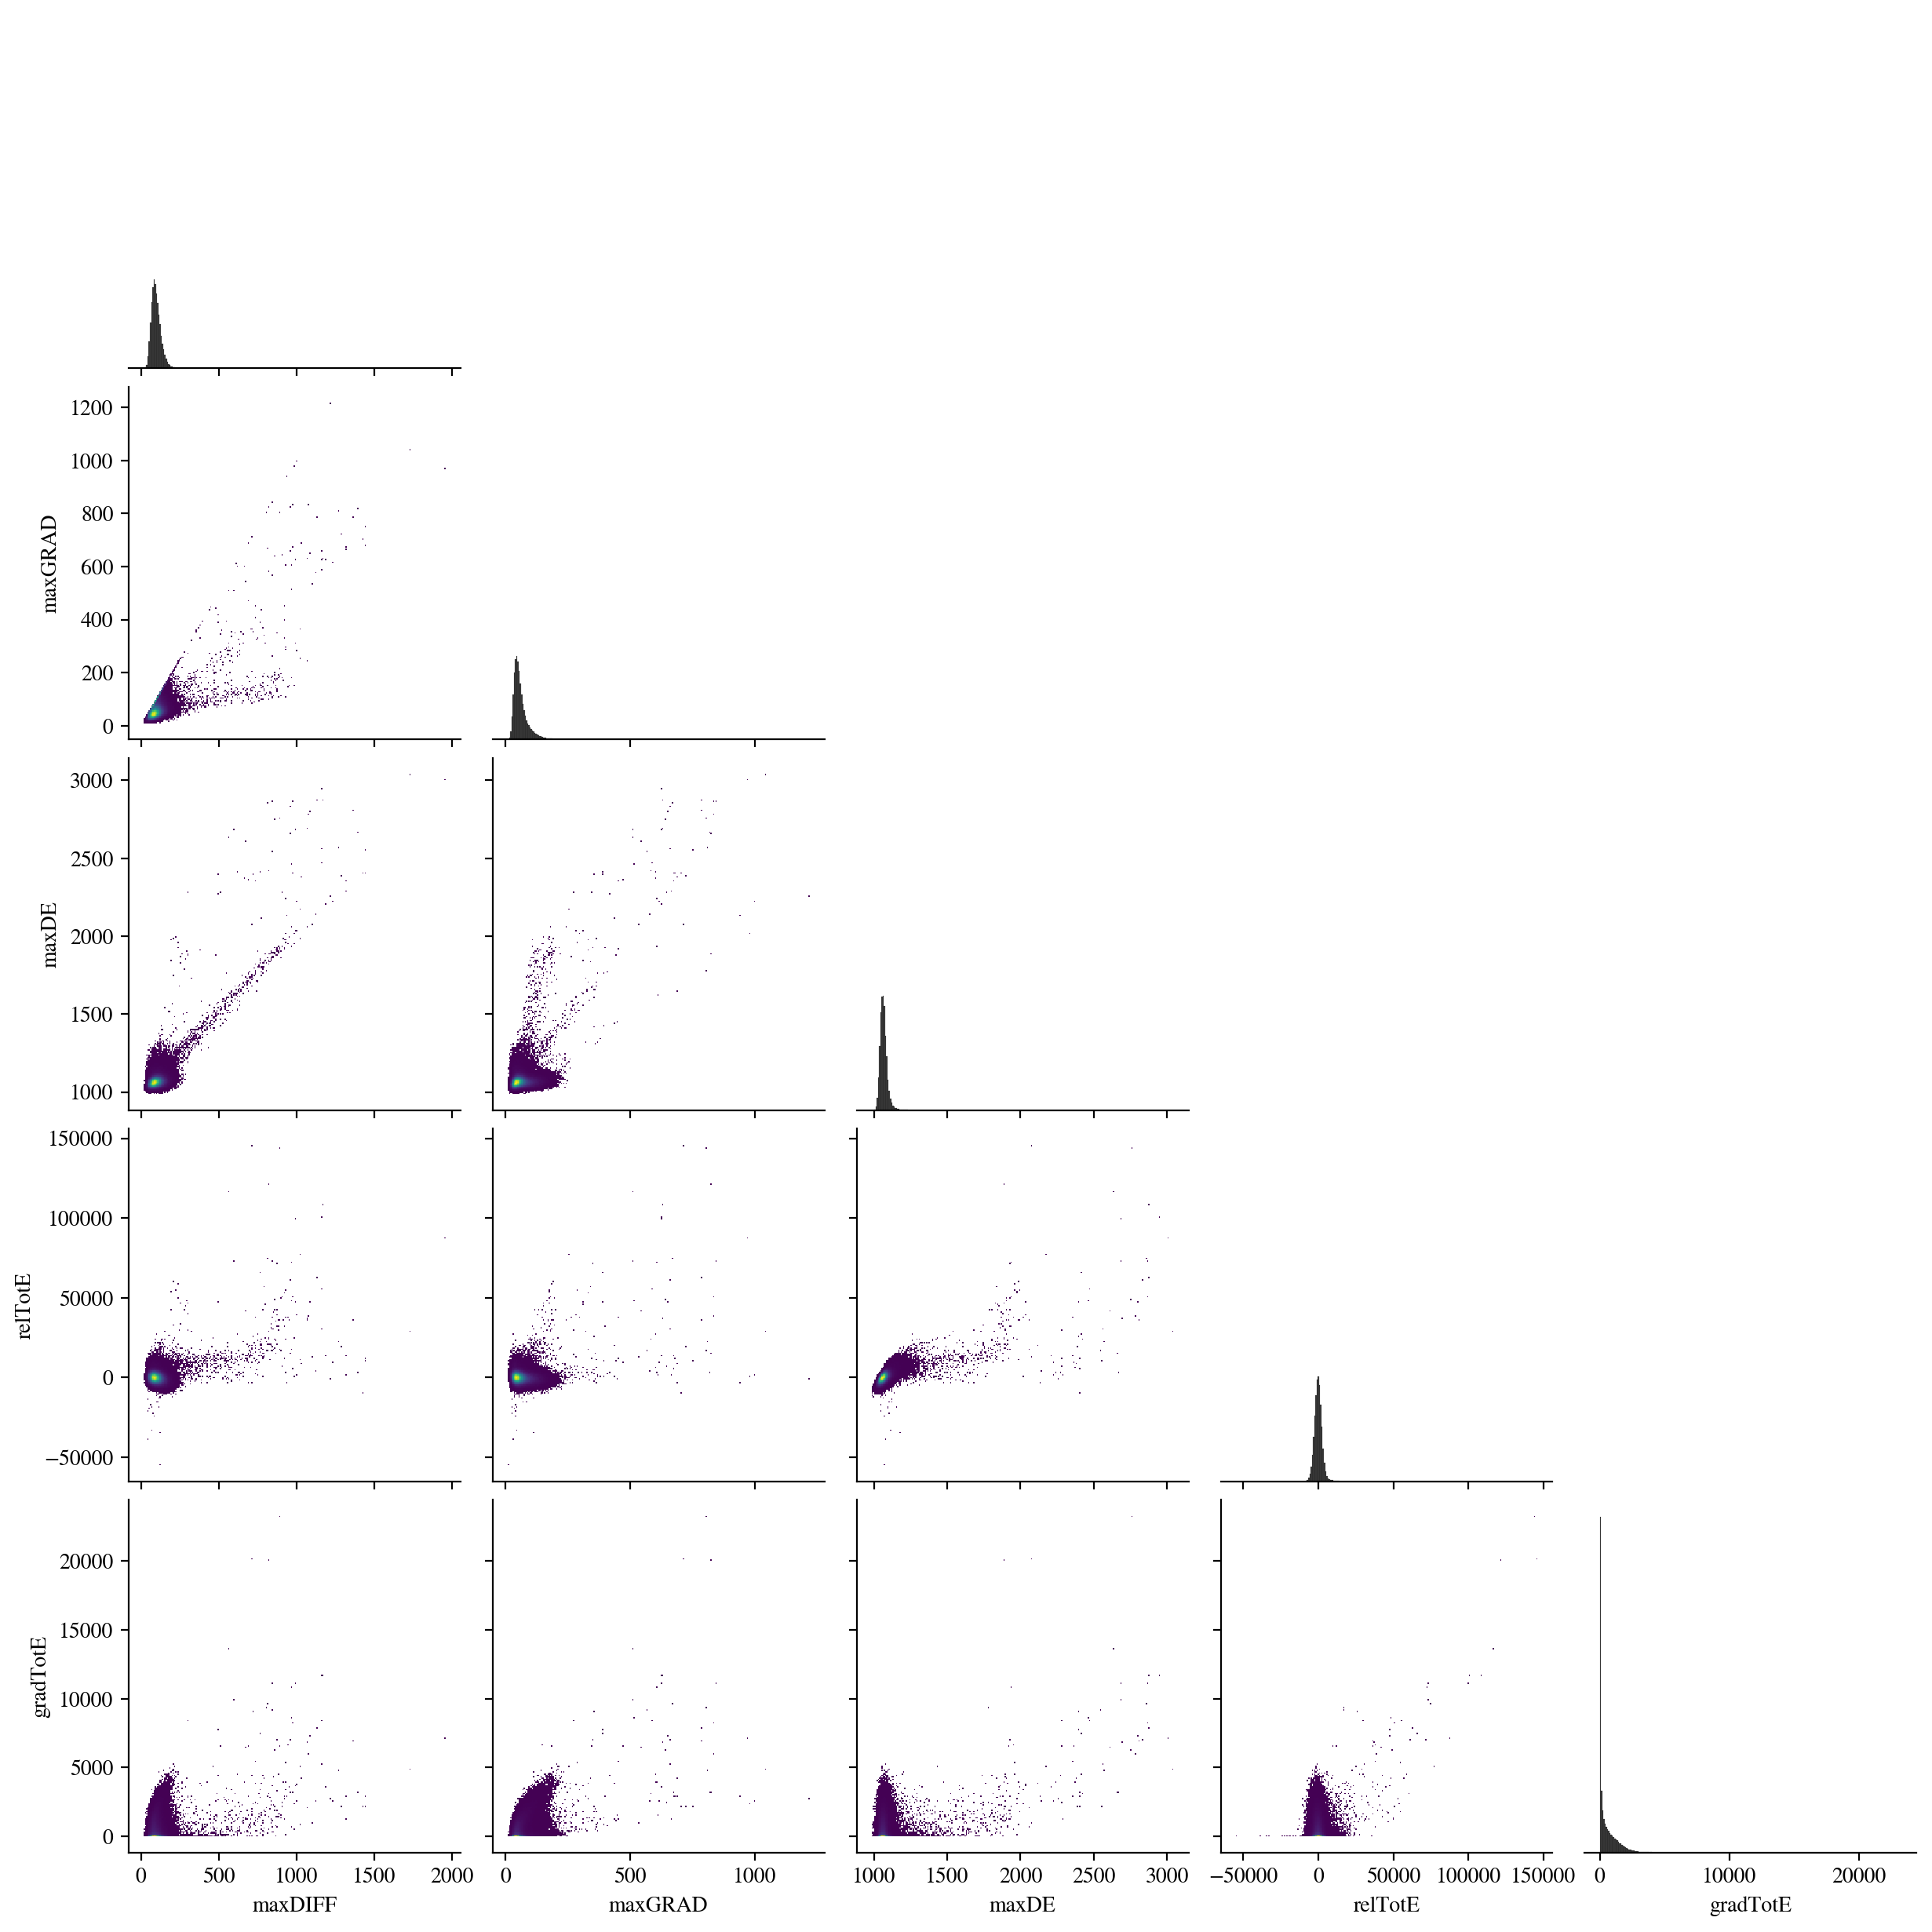

In [28]:
# Surpress UserWarning about changed layout
warnings.filterwarnings('ignore')

sns.pairplot(df_norm, vars=('maxDIFF', 'maxGRAD', 'maxDE', 'relTotE', 'gradTotE'), 
             kind='hist',
             corner=True,
             plot_kws={'bins':250, 'cmap':'viridis'},
             diag_kws={'bins':250, 'color':'black', 'log_scale':False})

In [23]:
yRcut = [250,1200] # [lower, upper]
xDcut = [0,100000] # [lower, upper]
# intRANGE cut
df_cut = df_norm.drop(df_norm[yRcut[0] > df_norm.maxGRAD].index, inplace=False) 
df_cut.drop(df_cut[yRcut[1] < df_cut.maxGRAD].index, inplace=True)
# maxDIFF cut
df_cut.drop(df_cut[xDcut[0] > df_cut.relTotE].index, inplace=True)
df_cut.drop(df_cut[xDcut[1] < df_cut.relTotE].index, inplace=True)
# must be less than beam in s17
df_cut.drop(df_cut[750 < df_cut.s17].index, inplace=True)

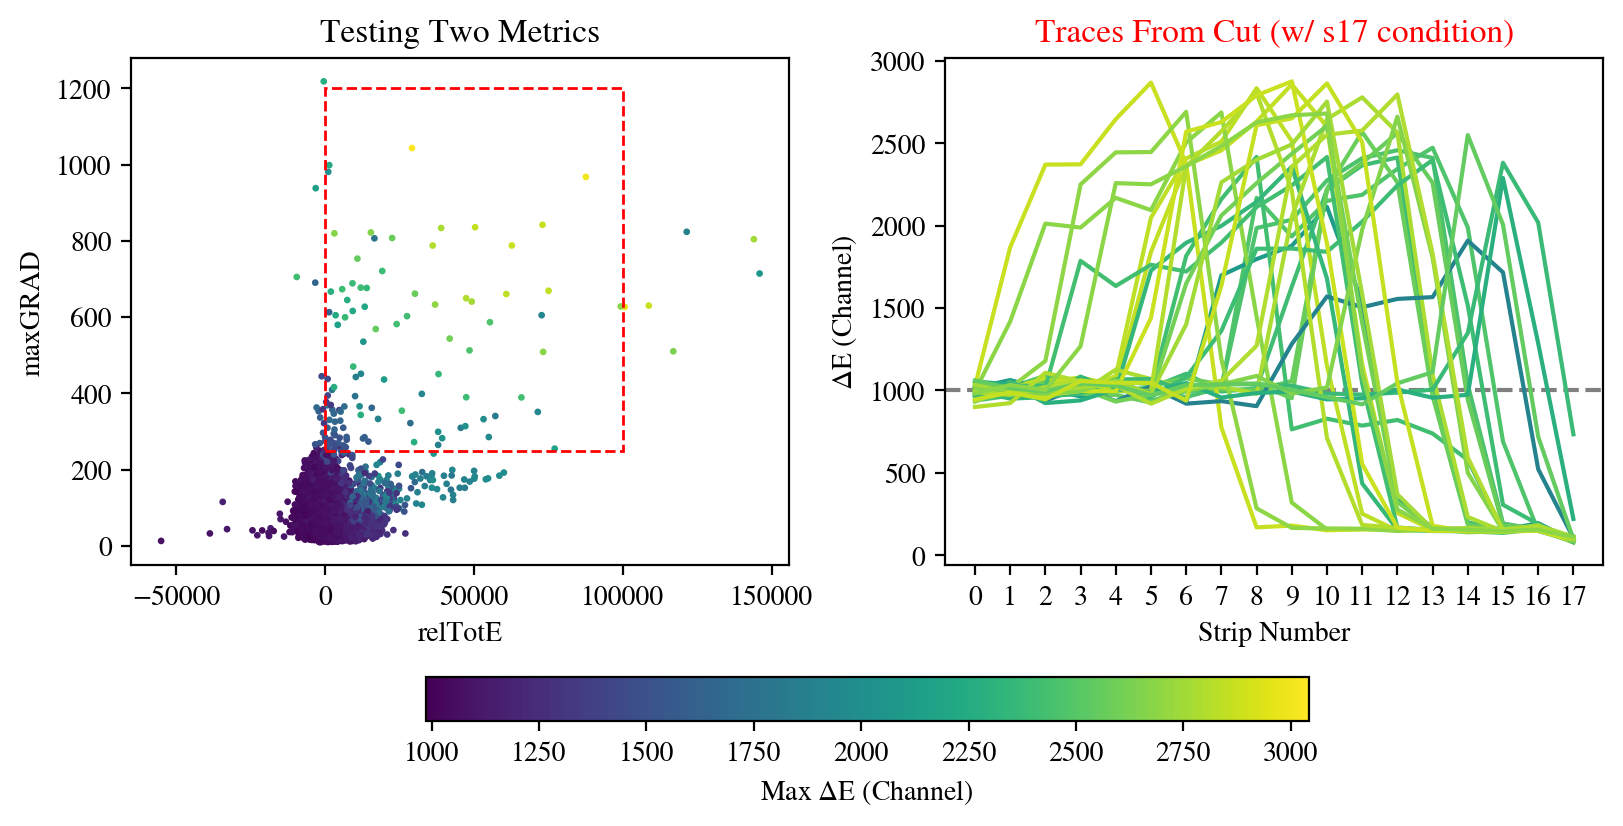

In [30]:
fig, ax = plt.subplots(1,2, layout='constrained')
# scatter
ax[0].set_title('Testing Two Metrics')
scplt = ax[0].scatter(df_norm['relTotE'], df_norm['maxGRAD'], c=df_norm['maxDE'], s=2)
# viz the cut
rect_cut = mpatches.Rectangle((xDcut[0],yRcut[0]), xDcut[1]-xDcut[0], yRcut[1]-yRcut[0],
                              edgecolor='r',
                              fill=False,
                              linestyle='--')
# rect_cut = mpatches.Rectangle((475,1.5), 1000, 11, edgecolor='r', fill=False, linestyle='--')
ax[0].add_patch(rect_cut)
# traces in Cut
## cmap values to match scatter
cmap = plt.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=df_norm['maxDE'].min(), vmax=df_norm['maxDE'].max())
colors = cmap(norm(df_cut['maxDE']))
# plot traces
ax[1].set_title('Traces From Cut (w/ s17 condition)', c='r')
for i in range(len(df_cut.index)):
    ax[1].plot(strip_num, df_cut.iloc[i,0:18], color=colors[i], zorder=10)
# viz beam avg
ax[1].axhline(1000.0, c='k', linestyle='--', alpha=0.5, zorder=1)
# cbar
fig.colorbar(scplt, ax=[ax[0],ax[1]],
             location='bottom',
             shrink=0.6,
             label=r'Max $\Delta$E (Channel)')
#
ax[0].set_xlabel('relTotE')
ax[0].set_ylabel('maxGRAD')
#
ax[1].set_xlabel('Strip Number')
ax[1].set_xticks(strip_num, strip_num)
ax[1].set_ylabel(r'$\Delta$E (Channel)')

fig.set_size_inches(8,4)
plt.show()